## Lobbying Network Analysis of Controversial Protest Buffer Bills 

#### Background & Research Question
The New York City City Council recently passed a bill focused on limiting protests around places of worship. There is a sister bill that does the same for Educational institutions. These controversial bills (Int. 001 and Int. 175) are opposed by institutions like the NYCLU, and other political factions thast argue such legislation would limit free speech in unconsitrutional. Especially in a place as dense as New York City. For the sake of this project, I will be attempting a network analysis on the organizations that worked to lobby NYCCC Members that sponsored at least one of the two bills - Intro. 001. I'm taking a look at the sponsors of this bill and then subsequently looking at the related lobbying information for early 2026, specifically January through February, to see what the network of entities that lobbied those elected officials on this matter. Ideally, such an analysis can reveal information about the coalitions and power brokers driving this legislation?

**Research Question:** Which client organizations formed the core lobbying coalition behind
Int. 001  & Int. 175, which actors served as structural brokers connecting otherwise disconnected
parts of that coalition, and which council member sponsors were the most strategic targets of the lobbying effort?


In [1]:
## Importing the relevant libs
import re, time, csv, os
import requests
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms import bipartite
from networkx.algorithms import community as nx_comm
import nltk
from nltk import FreqDist
from nltk.corpus import stopwords
from bs4 import BeautifulSoup


nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

## making data folder
os.makedirs("data", exist_ok=True)
pd.options.display.max_columns = 500
pd.options.display.max_rows    = 200

In [7]:
### Defining the functions that will be used to pull in data. (Scraping and via Scrata API)
def scrape_sponsors(url):
    """
    Scrapes all co-sponsor names from a Legistar bill page.
    Sponsors are stored as anchor tags linking to PersonDetail.aspx
    Returns a dict of {last_name_lower: full_name} for use in
    Socrata LIKE queries.
    """
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, 'html.parser')

    # ── Find all links pointing to PersonDetail.aspx ─────────
    # These are exclusively council member profile links
    sponsor_links = soup.find_all(
        'a',
        href=lambda h: h and 'PersonDetail.aspx' in h
    )

    sponsors = {}
    for link in sponsor_links:
        full_name = link.get_text(strip=True)
        if not full_name:
            continue

        # ── Extract last name for LIKE query matching ─────────
        # Handles middle initials: "Lynn C. Schulman" → "schulman"
        # Handles hyphenated names: "Brooks-Powers" → "brooks-powers"
        parts     = full_name.strip().split()
        last_name = parts[-1].lower()          # always last token
        sponsors[last_name] = full_name

    return sponsors

def fetch_resumable(url, params, csv_path, page_size=1000):
    """
    Paginated Socrata fetch with resume, append-to-CSV, and error recovery.
    
    FIX: Pages are now accumulated as DataFrames in memory and combined
    with pd.concat() rather than appended to CSV one by one. This prevents
    column misalignment caused by Socrata omitting null fields from some
    JSON responses — pd.concat() aligns on column names and fills NaN
    for any missing fields, keeping every value in the right column.
    """
    os.makedirs(
        os.path.dirname(csv_path) if os.path.dirname(csv_path) else ".",
        exist_ok=True
    )

    # ── Load existing progress if resuming ───────────────────
    if os.path.exists(csv_path):
        existing_df  = pd.read_csv(csv_path, dtype=str)
        rows_already = len(existing_df)
        start_offset = (rows_already // page_size) * page_size
        print(f"  Resuming '{csv_path}': {rows_already} rows already saved, "
              f"restarting from offset {start_offset}")
        # Seed the accumulator with what we already have
        all_pages = [existing_df]
    else:
        rows_already = 0
        start_offset = 0
        existing_df  = None
        all_pages    = []
        print(f"  Starting fresh: '{csv_path}'")

    params        = dict(params)
    offset        = start_offset
    total_fetched = rows_already

    while True:
        params["$limit"]  = page_size
        params["$offset"] = offset

        req = requests.Request('GET', url, params=params).prepare()
        print(f"  Requesting: {req.url}")

        try:
            r = requests.get(url, params=params, timeout=120)

            if r.status_code != 200:
                print(f"\n  ERROR {r.status_code} at offset {offset}:")
                print(f"  {r.text[:400]}")
                print(f"  Progress saved to {csv_path} — re-run to resume")
                r.raise_for_status()

            batch = r.json()

        except requests.exceptions.Timeout:
            print(f"\n  TIMEOUT at offset {offset} — re-run to resume")
            break
        except requests.exceptions.RequestException as e:
            print(f"\n  REQUEST ERROR at offset {offset}: {e}")
            break

        if not batch:
            print(f"  No results returned at offset {offset} — fetch complete")
            break

        # ── Key fix: accumulate as DataFrame, don't append to CSV ──
        # pd.concat() will later align all pages on column names,
        # filling NaN where a page was missing a field entirely
        batch_df = pd.DataFrame(batch)
        all_pages.append(batch_df)

        total_fetched += len(batch)
        print(f"  offset {offset:>8,}  |  page size: {len(batch)}  "
              f"|  total saved: {total_fetched:,}")

        # ── Save checkpoint after every page ─────────────────────
        # Concat everything so far and overwrite the CSV cleanly
        # This means resume always loads a correctly aligned file
        checkpoint_df = pd.concat(all_pages, ignore_index=True)
        checkpoint_df.to_csv(
            csv_path,
            index   = False,
            quoting = csv.QUOTE_ALL
        )

        if len(batch) < page_size:
            print(f"  Last page received — fetch complete")
            break

        offset += page_size
        time.sleep(0.3)

    print(f"\n  Done. Total rows saved: {total_fetched:,} → {csv_path}\n")

    if all_pages:
        # ── Final concat — aligns ALL columns across ALL pages ───
        final_df = pd.concat(all_pages, ignore_index=True)
        # Overwrite CSV one final time with the fully aligned result
        final_df.to_csv(csv_path, index=False, quoting=csv.QUOTE_ALL)
        print(f"  Columns in final dataset: {final_df.columns.tolist()}")
        return final_df
    elif os.path.exists(csv_path):
        # Resume case where no new pages were fetched
        return pd.read_csv(csv_path, dtype=str)
    else:
        print(f"  WARNING: No data was fetched — '{csv_path}' was not created")
        print(f"  Check the $where clause and confirm field names are correct")
        return pd.DataFrame()

### Starting with the Scraping of information on the bill's page on the NYCCC website. 
##### Were targeting for analysis, the NYCCC Members that sponsored this legistlation

In [20]:
bill_sponsors = scrape_sponsors("https://legistar.council.nyc.gov/LegislationDetail.aspx?ID=7861343&GUID=AF5DC0C4-C2EB-4C5D-861F-5B62DF8EA6EF")
print(f"Sponsors found: {len(bill_sponsors)}")
print(f"{'Last Name Key':<20} {'Full Name'}")

for last, full in bill_sponsors.items():
    print(f"  {last:<18} {full}")

Sponsors found: 35
Last Name Key        Full Name
  menin              Julie Menin
  vernikov           Inna Vernikov
  ariola             Joann Ariola
  dinowitz           Eric Dinowitz
  schulman           Lynn C. Schulman
  abreu              Shaun Abreu
  gennaro            James F. Gennaro
  ung                Sandra Ung
  louis              Farah N. Louis
  narcisse           Mercedes Narcisse
  lee                Linda Lee
  brewer             Gale A. Brewer
  hanks              Kamillah Hanks
  feliz              Oswald J. Feliz
  banks              Chris Banks
  zhuang             Susan Zhuang
  riley              Kevin C. Riley
  maloney            Virginia Maloney
  wong               Phil Wong
  williams           Nantasha M. Williams
  encarnación        Elsie Encarnación
  sanchez            Justin E. Sanchez
  salaam             Yusef Salaam
  hankerson          Ty Hankerson
  mealy              Darlene Mealy
  marte              Christopher Marte
  krishnan           Sh

In [37]:
### Generatiing a where clause to add to the socrate api based on the rating
custom_where_nyccc = ""
start = "upper(party_name) like '%"
for k in bill_sponsors.keys():
    val = bill_sponsors[k].split(' ')[0]
    
    if k == list(bill_sponsors.keys())[-1]:
        running = start +val.upper().strip()+'%'+k.upper().strip() +"%' "
    else:
        running = start +val.upper().strip()+'%'+ k.upper().strip() +"%' OR "
    custom_where_nyccc = custom_where_nyccc+running

In [58]:
### Pulling inthe lobbying data from State Lovbvbying Bi-Monthly Reports
NYCCC = "NYC COUNCIL MEMBER"
DS_BIMONTHLY = "t9kf-dqbc"   # Lobbyist Bi-Monthly Reports: Beginning 2019# https://data.ny.gov/Transparency/Lobbyist-Bi-Monthly-Reports-Beginning-2019/t9kf-dqbc/about_data
BASE_URL     = f"https://data.ny.gov/resource/{DS_BIMONTHLY}.json"
df_raw = fetch_resumable(
    url      = BASE_URL,
    params   = {
        "$where" : (
            "government_body = 'NYC Council Members and County Legislators' "
            "AND (reporting_period = 'Jan/Feb' OR reporting_period = 'Mar/Apr') "# NOTE: March and APril are not available, and were not pulled
            "AND reporting_year = 2026 "
            f"AND ({custom_where_nyccc})"
        ),
        "$order" : "principal_lobbyist_name ASC"
    },
    csv_path = "data/nyccc2026_all.csv"
)

  Starting fresh: 'data/nyccc2026_all.csv'
  Requesting: https://data.ny.gov/resource/t9kf-dqbc.json?%24where=government_body+%3D+%27NYC+Council+Members+and+County+Legislators%27+AND+%28reporting_period+%3D+%27Jan%2FFeb%27+OR+reporting_period+%3D+%27Mar%2FApr%27%29+AND+reporting_year+%3D+2026+AND+%28upper%28party_name%29+like+%27%25JULIE%25MENIN%25%27+OR+upper%28party_name%29+like+%27%25INNA%25VERNIKOV%25%27+OR+upper%28party_name%29+like+%27%25JOANN%25ARIOLA%25%27+OR+upper%28party_name%29+like+%27%25ERIC%25DINOWITZ%25%27+OR+upper%28party_name%29+like+%27%25LYNN%25SCHULMAN%25%27+OR+upper%28party_name%29+like+%27%25SHAUN%25ABREU%25%27+OR+upper%28party_name%29+like+%27%25JAMES%25GENNARO%25%27+OR+upper%28party_name%29+like+%27%25SANDRA%25UNG%25%27+OR+upper%28party_name%29+like+%27%25FARAH%25LOUIS%25%27+OR+upper%28party_name%29+like+%27%25MERCEDES%25NARCISSE%25%27+OR+upper%28party_name%29+like+%27%25LINDA%25LEE%25%27+OR+upper%28party_name%29+like+%27%25GALE%25BREWER%25%27+OR+upper%28party_n

### I have the Lobbying Data for these Bill Sponsors, Time to Process and Analyze it

In [216]:
### Manually Reveiwing the Focus Identifying Number for the Lobbying of this Bill
[print(i) for i in df_raw['focus_identifying_number'].unique() if 'intro' in str(i).lower()]
# There are only two obvious entries found that seem to relate DIRECTLY to the bill of interest. They are: 'Intro. 1 2026','Intro 0001'
## Starting there, and adjusting further as more are found. 

Intro 0518
intro 30
Site tour and Intro 518
Intro 518
Intro - 1152
Intro-0641
Intro 0090-2026
intro 276
Regarding general introduction to Amplify Education, Inc. as it relates to the interests of the City of New York
Regarding request for introductory meeting and site visit with BronxWorks, Inc. in the City of New York
Regarding general introduction to The Children's Rescue Fund as it relates to the interests of the City of New York
Regarding NYC Intro 1451 requiring the New York City police department to provide the civilian complaint review board with direct access to officer body-warn camera footage and to establish related procedures in the City of New York
Regarding NYC Intro 1452 requiring notice and provision to fire department personnel of firefighting personal protective equipment containing perfluoroalkyl and polyfluoroalkyl substances in the City of New York
Regarding NYC Intro 101 related to City FHEPS (Fighting Homelessness and Eviction Protection Supplement) application r

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [218]:
### Taking a look at the other columns for these two specific values to use the Lobbying SUbjects, The lobbying Focus Types and 
### other contextual information. We will use all of these columns in conjunction in order to limit to our final universe for analysis.
# df_raw[df_raw['focus_identifying_number'].isin(['Intro. 1 2026','Intro 0001'])]

In [79]:
### Rather than stay just with those two entry values, were going to take all of the contextual information and limit on those, along 
### with the focus_identifying_number considered as well. However, this will allow for a larger universe for analysis. 
indent_num_lim = ['Intro. 1 2026','Intro 0001','Int. 1, buffer zones adjacent to houses of worship..','Int. No. 1','Int. 1','NYC Int 1-2026',
                  ### This one is for a sister bill for eudcational places, so keeping it in for now
                  'Int. 175, buffer zones adjacent to educational institutions.','NYC Int 175-2026', 'Int. 175','Intro 175 2026',
                  ### THese are generic enough to be included
                  'New introductions/bills + Int. 0448-2026; Int. 0438-2026; Int.0022-2026; Int. 0596-2026; Res. 0069-2026; Res. 0062-2026; Int. 0295-2026',
                  'New Policy Proposal','Potential Legislation',
                  'Buffer Zone Bill','Buffer Zones Bill']

limiting_subjects = list(df_raw['lobbying_subjects'][df_raw['focus_identifying_number'].isin(indent_num_lim)].unique())
print(limiting_subjects)
limiting_focus_type = list(df_raw['lobbying_focus_type'][df_raw['focus_identifying_number'].isin(['Intro. 1 2026','Intro 0001'])].unique())
print(limiting_focus_type)


['Media - General', 'Education - general', 'Budget/Appropriations', 'Human Rights/Civil Rights', 'Real Estate – General', 'Education – Funding', 'Health – General', 'Criminal Justice – general', 'Criminal Justice – Police Issues', 'Criminal Justice – Law Enforcement', 'Health – Hospitals & Nursing Homes', 'Criminal Justice – Criminal Law & Procedures (includes sentencing)', 'Media – First Amendment – Press', 'Public Utilities - Telecommunications', 'Corrections', 'Labor –  General', 'Labor – Prevailing wage/ Minimum Wage', 'Insurance - Health', 'Consumer Issues/Safety/Protection', 'Labor - Labor Issues/ Unions', 'Tax – General', 'Economic Development - general', 'Veterans Affairs']
['Municipal Bill']


In [219]:
### limited based on contextual values
limited_df = df_raw[((df_raw['lobbying_focus_type'].isin(limiting_focus_type))
                     &(df_raw['lobbying_subjects'].isin(limiting_subjects)))]
### Taking a look at the focus_identifying_number values here 
# sorted(limited_df['focus_identifying_number'].unique())
### I think we got all of the values needed for this. To limit to our final universe. 

In [220]:
##Over Inclusive, by limiting to both the Intro 001 and intro 175, which are both buffer zones for politcal protest.  
final_universe =  df_raw[((df_raw['lobbying_focus_type'].isin(limiting_focus_type))  
                          &(df_raw['lobbying_subjects'].isin(limiting_subjects))
                         &(df_raw['focus_identifying_number'].isin(indent_num_lim)))]
print(final_universe.shape)

(563, 37)


In [221]:
## FInal list of those lobbied on these bills that also sponsored Into 001
final_universe['party_name'].unique()

array(['NYC Council Member Julie Menin',
       'NYC Council Member Julie Menin, staff member',
       'NYC Council Member Yusef Salaam',
       'NYC Council Member Shanel Thomas-Henry',
       'NYC Council Member Oswald Feliz',
       'NYC Council Member Nantasha Williams',
       'NYC Council Member Tyrell Hankerson, staff member',
       'NYC Council Member Darlene Mealy, staff member',
       'NYC Council Member Farah N. Louis, staff member',
       'NYC Council Member Kevin Riley, staff member',
       'NYC Council Member Mercedes Narcisse, staff member',
       'NYC Council Member Eric Dinowitz',
       'NYC Council Member Lynn Schulman',
       'NYC Council Member Kevin Riley', 'NYC Council Member Gale Brewer'],
      dtype=object)

In [222]:
final_universe['beneficial_client_name'].unique()

array(['ANTI-DEFAMATION LEAGUE;', 'Orange Barrel Media, LLC;',
       'GIRLS FOR GENDER EQUITY, INC. (GGE);',
       'NEW YORK CIVIL LIBERTIES UNION, INC.;',
       'DETECTIVES ENDOWMENT ASSOCIATION POLICE DEPARTMENT, CITY OF NEW YORK INC.;',
       "CORRECTION OFFICERS' BENEVOLENT ASSOCIATION, INC.;",
       "CAPTAINS' ENDOWMENT ASSOCIATION OF THE POLICE DEPARTMENT OF THE CITY OF NEW YORK, INC. (THE);",
       'New York City Central Labor Council AFL-CIO;',
       'LIEUTENANTS BENEVOLENT ASSOCIATION OF THE CITY OF NEW YORK, INC.;',
       'SERVICE EMPLOYEES INTERNATIONAL UNION, LOCAL 32BJ;',
       'UNITED JEWISH APPEAL-FEDERATION OF JEWISH PHILANTHROPIES OF NEW YORK, INC.;',
       'URBAN JUSTICE CENTER;'], dtype=object)

In [225]:
final_universe.head()

,form_submission_id,reporting_year,filing_type,reporting_period,principal_lobbyist_name,contractual_client_name,beneficial_client_name,individual_lobbyist_name,compensation,reimbursed_expenses,expenses_less_than_75,lobbying_expenses_for_non,itemized_expenses,expense_type,expense_paid_to,expense_reimbursed_by_client,expense_purpose,expense_date,lobbying_subjects,level_of_government,lobbying_focus_type,focus_identifying_number,type_of_lobbying_communication,government_body,monitoring_only,party_name,unique_id,sub_lobbyist,coalition_name,contribution_amount,was_an_expense_incurred_on,total_amount_of_the_expense,was_the_expense_paid_for,if_pooled_funds_were_used,total_contribution_amount,coalition_contribution_expense,co_lobbyist
9759,786374,2026,Original,Jan/Feb,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE;,"Richman, Scott; Augenbraun, Melissa; PLAFKER-GUTT, DEBRA; Sims, Cathleen;",4594,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Media - General,Both (State and Municipal),Municipal Bill,Buffer Zone Bill,Direct Lobbying,NYC Council Members and County Legislators,No,NYC Council Member Julie Menin,786374-55-0-0-0-19-MBIL-14813-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9760,786374,2026,Original,Jan/Feb,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE;,"Richman, Scott; Augenbraun, Melissa; PLAFKER-GUTT, DEBRA; Sims, Cathleen;",4594,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Education - general,Both (State and Municipal),Municipal Bill,Buffer Zone Bill,Direct Lobbying,NYC Council Members and County Legislators,No,NYC Council Member Julie Menin,786374-13-0-0-0-19-MBIL-14813-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9761,786374,2026,Original,Jan/Feb,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE;,"Richman, Scott; Augenbraun, Melissa; PLAFKER-GUTT, DEBRA; Sims, Cathleen;",4594,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Budget/Appropriations,Both (State and Municipal),Municipal Bill,Buffer Zone Bill,Direct Lobbying,NYC Council Members and County Legislators,No,NYC Council Member Julie Menin,786374-45-0-0-0-19-MBIL-14813-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9762,786374,2026,Original,Jan/Feb,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE;,"Richman, Scott; Augenbraun, Melissa; PLAFKER-GUTT, DEBRA; Sims, Cathleen;",4594,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Human Rights/Civil Rights,Both (State and Municipal),Municipal Bill,Buffer Zone Bill,Direct Lobbying,NYC Council Members and County Legislators,No,"NYC Council Member Julie Menin, staff member",786374-44-0-0-0-19-MBIL-14814-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9763,786374,2026,Original,Jan/Feb,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE,ANTI-DEFAMATION LEAGUE;,"Richman, Scott; Augenbraun, Melissa; PLAFKER-GUTT, DEBRA; Sims, Cathleen;",4594,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Education - general,Both (State and Municipal),Municipal Bill,Buffer Zone Bill,Direct Lobbying,NYC Council Members and County Legislators,No,"NYC Council Member Julie Menin, staff member",786374-13-0-0-0-19-MBIL-14814-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
### Cleaning the text to take a look at the data in certain columns.
def normalize_name(text):
    if pd.isna(text): return None
    text = str(text).strip().lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s\-\']', '', text)
    return text.strip()

# Implememnting cleaning  
final_universe['lobbyist_clean'] = final_universe['principal_lobbyist_name'].apply(normalize_name)
final_universe['client_clean']   = final_universe['contractual_client_name'].apply(normalize_name)
final_universe['party_clean']    = final_universe['party_name'].apply(normalize_name)
final_universe['subject_clean']  = final_universe['lobbying_subjects'].apply(normalize_name)

before = len(final_universe)
final_universe_lim = final_universe.dropna(subset=['lobbyist_clean', 'client_clean', 'party_clean']).copy()
print(f"Dropped {before - len(final_universe_lim)} rows missing key fields → {len(final_universe_lim)} graph-ready rows")

Dropped 0 rows missing key fields → 563 graph-ready rows


C:\Users\jferrara_personal\AppData\Local\Temp\ipykernel_150808\2036063710.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_universe['lobbyist_clean'] = final_universe['principal_lobbyist_name'].apply(normalize_name)
C:\Users\jferrara_personal\AppData\Local\Temp\ipykernel_150808\2036063710.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_universe['client_clean']   = final_universe['contractual_client_name'].apply(normalize_name)
C:\Users\jferrara_personal\AppData\Local\Temp\ipykernel_1508

In [102]:
print("FREQ DIST: TOP 20 CLIENT ORGANIZATIONS")
## looking at the top clients based on the number of times they show up in the data, or basically how many times they lobbied for these bills. 
fdist_clients = FreqDist(final_universe_lim['client_clean'].dropna())
for client, count in fdist_clients.most_common(20):
    print(f"  {count:>4}  {client}")

FREQ DIST: TOP 20 CLIENT ORGANIZATIONS
   288  new york civil liberties union inc
   140  girls for gender equity inc gge
    95  urban justice center
    12  orange barrel media llc
     8  anti-defamation league
     7  service employees international union local 32bj
     3  united jewish appeal-federation of jewish philanthropies of new york inc
     2  detectives endowment association police department city of new york inc
     2  correction officers' benevolent association inc
     2  captains' endowment association of the police department of the city of new york inc the
     2  new york city central labor council afl-cio
     2  lieutenants benevolent association of the city of new york inc


Taking a look at this the Top lobbying client was the NYCLU, which as I mentionewd before is a prominent opponent to this legislation. 
The other top clients that did a lot of lobbying on these bills are the Urban Justice Center, Girls for Gender Equality, Orange Barrel Media, 
the anti-defamation league, and SEIU 32BJ. Beyond these clients, there are other than only have 2 appearances in the data, so these entities 
dids not lobby as much. 

In [103]:
print("FREQ DIST: TOP 20 LOBBYIST FIRMS")
fdist_lob = FreqDist(final_universe_lim['lobbyist_clean'].dropna())
for firm, count in fdist_lob.most_common(20):
    print(f"  {count:>4}  {firm}")

FREQ DIST: TOP 20 LOBBYIST FIRMS
   288  new york civil liberties union inc
   140  girls for gender equity inc gge
    95  urban justice center
    12  fontas advisors ny llc
    10  pitta bishop  del giorno llc
     8  anti-defamation league
     7  service employees international union local 32bj
     3  united jewish appeal-federation of jewish philanthropies of new york inc


Taking a look at this, NYCLU, GGE, the Urban Justice Center, the ADL, and SEIU 32BJ all did not hire another firm for lobbying work, but rather lobbied themselves. Other firms did seem to hire some lobbying firms to help with their efforts. 

In [105]:
print("FREQ DIST: COUNCIL MEMBERS LOBBIED")
### Further clean ing staff member versus the actual official in order to be able to say "the office was lobbied"
final_universe_lim['party_clean_office'] = final_universe_lim['party_clean'].astype(str).str.replace('staff member','').str.strip()
fdist_cm = FreqDist(final_universe_lim['party_clean_office'].dropna())
for cm, count in fdist_cm.most_common(20):
    print(f"  {count:>4}  {cm}")

FREQ DIST: COUNCIL MEMBERS LOBBIED
   312  nyc council member julie menin
    50  nyc council member kevin riley
    36  nyc council member eric dinowitz
    28  nyc council member tyrell hankerson
    28  nyc council member darlene mealy
    28  nyc council member farah n louis
    28  nyc council member mercedes narcisse
    26  nyc council member gale brewer
    20  nyc council member nantasha williams
     2  nyc council member yusef salaam
     2  nyc council member shanel thomas-henry
     2  nyc council member oswald feliz
     1  nyc council member lynn schulman


Taking a look at the city council members that were lobbied on this, by far the one most lobbied was Julie Menin the current speaker.
Her office was lobbied a total of 312 times, according to the data. 
In second place, is Kevin Riley, with a large drop of in instances lobbied, he was lobbied 50 times. 
In third was Eric Dinowitz who was lobbied 36 times. All the other NYCCC members were lobbied 20 times or less. 

### Starting with the Network 

In [109]:
### Putting the final cleaned universe into a network with network x for analysis.
### CLients and NYCCC Members are nodes with the edges being weighted by the numberof times lobbied.
### Were going to keep in lobbying firms as edge attributes as well as the compensation  spent lobbying
B = nx.Graph()
for _, row in final_universe_lim.iterrows():
    client  = "C:" + str(row['client_clean'])
    council = "M:" + str(row['party_clean_office'])
    comp    = int(row['compensation']) if pd.notna(row['compensation']) else 0
    firm    = str(row['lobbyist_clean'])
    subject = str(row['subject_clean']) if pd.notna(row['subject_clean']) else ''

    # Lobbying clients, essentially those wanting to influence policy
    B.add_node(client)
    B.nodes[client].setdefault('node_type',    'client')
    B.nodes[client].setdefault('filing_count', 0)
    B.nodes[client].setdefault('total_comp',   0)
    B.nodes[client].setdefault('firms',        set())
    B.nodes[client]['filing_count'] += 1
    B.nodes[client]['total_comp']   += comp
    B.nodes[client]['firms'].add(firm)

    # Council member nodes 
    B.add_node(council)
    B.nodes[council].setdefault('node_type',    'council_member')
    B.nodes[council].setdefault('filing_count', 0)
    B.nodes[council].setdefault('total_comp',   0)
    B.nodes[council]['filing_count'] += 1
    B.nodes[council]['total_comp']   += comp
    # Keeping the other info as attribs 
    if B.has_edge(client, council):
        B[client][council]['weight']   += 1
        B[client][council]['comp']     += comp
        B[client][council]['firms'].add(firm)
    else:
        B.add_edge(client, council,
                   weight=1, comp=comp, firms={firm})

In [111]:
### Specifc sets of nodes for the two types (adding prefix for no confusion with names) 
client_nodes  = {n for n in B.nodes() if n.startswith('C:')}
council_nodes = {n for n in B.nodes() if n.startswith('M:')}

print(f" The number of clients who sought to lobby elected officials on these two bills: {len(client_nodes)}")
print(f" The number of NYCCC Members that were lobbied on these two bills: {len(council_nodes)}")
print(f"  THe connections / edges for these two sets of nodes: {B.number_of_edges()}")
print(f"  Bipartite COnfirmation (why we had the prefixes): {bipartite.is_bipartite(B)}")
print(f"  Graph density (of all connections that could exist, how many do.): {nx.density(B):.4f}")

 The number of clients who sought to lobby elected officials on these two bills: 12
 The number of NYCCC Members that were lobbied on these two bills: 13
  THe connections / edges for these two sets of nodes: 24
  Bipartite COnfirmation (why we had the prefixes): True
  Graph density (of all connections that could exist, how many do.): 0.0800


Taking a look at these graph stats. There are 12 clients lobbying 13 NYCCC Members on these bills.
There are a total of 24 edges / connections in this graph between the node types. 
The graph density is low (~8%) meaning the lobbying efforts were focused on a small subset of NYCCC sponsors of the bill.

In [115]:
### Projecting the bipartite grpah into one dimensions, specifically for clients. 
### ALlows us to see potential lobying coalitions for those attempting to influence
### Essentially those that lobbied the same officials, with the officials removed are now connected. 
G_client = bipartite.weighted_projected_graph(B, client_nodes)
G_client = nx.relabel_nodes(G_client, {n: n[2:] for n in G_client.nodes()})
for node in G_client.nodes():
    pref = "C:" + node
    G_client.nodes[node]['filing_count'] = B.nodes[pref].get('filing_count', 0)
    G_client.nodes[node]['total_comp']   = B.nodes[pref].get('total_comp', 0)

print(f"Client projection edges : {G_client.number_of_edges()}")
print(f"Client graph density: {nx.density(G_client):.4f}")


Client projection edges : 39
Client graph density: 0.5909


There are a total of 39 edges in the data and the density is ~60%. This means that more than half of the 
clients lobbying on this bill lobbied the same city council members. The high overlap indicates a potential lobbying coalition, 
at least for those that share the same stance on the bills. Regardles, those lobbying on this bill seem to have similar strategies on who needs to be aligned with their stance in order to stop/progress the bills.

In [116]:
### Similarly now were taking a look at the NYCCC Member side of the biopartite graph to see the network of those in power that 
### were lobbied on these bills. 
G_council = bipartite.weighted_projected_graph(B, council_nodes)
G_council = nx.relabel_nodes(G_council, {n: n[2:] for n in G_council.nodes()})
for node in G_council.nodes():
    pref = "M:" + node
    G_council.nodes[node]['filing_count'] = B.nodes[pref].get('filing_count', 0)
    G_council.nodes[node]['total_comp']   = B.nodes[pref].get('total_comp', 0)

print(f"  Council projection edges: {G_council.number_of_edges()}")
print(f"  Council graph density   : {nx.density(G_council):.4f}")

  Council projection edges: 27
  Council graph density   : 0.3462


There are a totel of 27 different edges present along with a density of about ~35%. THis means that about 1/3 of the potential links for these 
NYCCC members were made. 

So far the numbers from both of these projections imply that those clients that were lobbying for/against these bills were 
related entities targeting a subset of NYCCC members. 

Additionally, the NYCCC side of the graph is less dense meaning that there was more targeted effort for NYCCC members. This suggests that while clients
moved as a bloc, their lobbying was more targeted toward specific council members rather than
blanketing all sponsors equally. THis aligns with the over 300 instances of Speaker Menin's office being lobbied. WIth the steep drop off for the runners up. 

### Looking at Centrality measures in this section

In [127]:
pd.options.display.max_colwidth = 200

#### Degree Centrality

In [130]:
### For the Client side of the equation
### Showing how many other clients that the organization has overlap with when looking at their NYCCC Member targets.
degree_cent = nx.degree_centrality(G_client)
client_centrality = pd.DataFrame([degree_cent]).T
client_centrality = client_centrality.reset_index()
client_centrality.columns = ['Client',"Degree Centrality"]
client_centrality.sort_values(by='Degree Centrality', ascending=False)

,Client,Degree Centrality
10,orange barrel media llc,0.818182
0,united jewish appeal-federation of jewish philanthropies of new york inc,0.727273
3,detectives endowment association police department city of new york inc,0.727273
2,captains' endowment association of the police department of the city of new york inc the,0.727273
9,anti-defamation league,0.727273
4,new york city central labor council afl-cio,0.727273
8,lieutenants benevolent association of the city of new york inc,0.727273
5,new york civil liberties union inc,0.727273
11,correction officers' benevolent association inc,0.727273
6,urban justice center,0.272727


In [133]:
### For the Council Member side of the equation
### Showing how many NYCCC Members were targeted by the same lobbying clients 
degree_cent = nx.degree_centrality(G_council)
council_centrality = pd.DataFrame([degree_cent]).T
council_centrality = council_centrality.reset_index()
council_centrality.columns = ['NYCCC_MEMBER',"Degree Centrality"]
council_centrality.sort_values(by='Degree Centrality', ascending=False)

,NYCCC_MEMBER,Degree Centrality
2,nyc council member kevin riley,0.583333
10,nyc council member nantasha williams,0.583333
9,nyc council member julie menin,0.416667
0,nyc council member farah n louis,0.333333
3,nyc council member shanel thomas-henry,0.333333
11,nyc council member mercedes narcisse,0.333333
4,nyc council member darlene mealy,0.333333
8,nyc council member tyrell hankerson,0.333333
7,nyc council member yusef salaam,0.333333
12,nyc council member oswald feliz,0.333333


Overall when looking at degree centrality here for the client and the Council Member side, one can infer that Orange Barrel Media has the most
target overlap with other clients lobbying council members. While the outliers, and potential "out of the box" strategy thinkers for their 
influence on the bill was the SEIU 32BJ and GGE, as they had the lowest centrlity scores. In short, they didnt necessarily lobby the same NYCCC 
Memebers all the other clients did.

Similarly, Kevin Riley, Julie Menin, and Nantasha Williams were the NYCCC members that had the most overlap for those clients lobbying officials.
Where Lynn Schulman, with the lowest degree centrality, was lobbied on this bill, by the more peripheral clients. 

#### Betweenness Centrality

In [229]:
### Client SIde 
between_cent = nx.betweenness_centrality(G_client, weight='weight', normalized=True)
client_between_cent = pd.DataFrame([between_cent]).T
client_between_cent = client_between_cent.reset_index()
client_between_cent.columns = ['Client',"Between Centrality"]
client_between_cent.sort_values(by='Between Centrality', ascending=False)

,Client,Between Centrality
10,orange barrel media llc,0.436364
6,urban justice center,0.345455
0,united jewish appeal-federation of jewish philanthropies of new york inc,0.000000
1,girls for gender equity inc gge,0.000000
3,detectives endowment association police department city of new york inc,0.000000
2,captains' endowment association of the police department of the city of new york inc the,0.000000
5,new york civil liberties union inc,0.000000
4,new york city central labor council afl-cio,0.000000
7,service employees international union local 32bj,0.000000
8,lieutenants benevolent association of the city of new york inc,0.000000


Only two clients got a Between Centrality score that is over 0, they were Orange Barrel Media and the Urban Justice Center. 
Both of these lobbying clients and their efforts were the ones that arguably transcended the traditioinal coalitions as they seemed to
be the connections between the different factions concerned about the bill. 

In [139]:
### Council Member SIde
between_cent = nx.betweenness_centrality(G_council, weight='weight', normalized=True)
council_between_cent = pd.DataFrame([between_cent]).T
council_between_cent = council_between_cent.reset_index()
council_between_cent.columns = ['NYCCC_MEMBER',"Between Centrality"]
council_between_cent.sort_values(by='Between Centrality', ascending=False)

,NYCCC_MEMBER,Between Centrality
10,nyc council member nantasha williams,0.530303
2,nyc council member kevin riley,0.484848
9,nyc council member julie menin,0.166667
0,nyc council member farah n louis,0.000000
1,nyc council member lynn schulman,0.000000
4,nyc council member darlene mealy,0.000000
3,nyc council member shanel thomas-henry,0.000000
5,nyc council member gale brewer,0.000000
6,nyc council member eric dinowitz,0.000000
8,nyc council member tyrell hankerson,0.000000


Based on the betweenness centrality, NYCCC Meber Natasha Williams and Kevin Riley had the highest scores here. WIth Julie Menin in third.
All the other NYCCC Members had a score of 0. This means that these members (Willams and Riley) were approached by lobbying clients
that did not otherwise overlap with one another. They connected discrete portions of these lobbying coalitions, which implys a strategic targeting
by lobbyists. This could imply a higher degree of power pertaining to these bills in this instance for this members.

#### PageRank

In [230]:
## Client Side
pagerank = nx.pagerank(G_client, weight='weight')
client_pr= pd.DataFrame([pagerank]).T
client_pr = client_pr.reset_index()
client_pr.columns = ['Client',"PageRank"]
client_pr.sort_values(by='PageRank', ascending=False)

,Client,PageRank
10,orange barrel media llc,0.114017
0,united jewish appeal-federation of jewish philanthropies of new york inc,0.090803
3,detectives endowment association police department city of new york inc,0.090803
2,captains' endowment association of the police department of the city of new york inc the,0.090803
9,anti-defamation league,0.090803
4,new york city central labor council afl-cio,0.090803
8,lieutenants benevolent association of the city of new york inc,0.090803
5,new york civil liberties union inc,0.090803
11,correction officers' benevolent association inc,0.090803
6,urban justice center,0.085890


In [143]:
## Council Side
pagerank = nx.pagerank(G_council, weight='weight')
council_pr= pd.DataFrame([pagerank]).T
council_pr = council_pr.reset_index()
council_pr.columns = ['NYCCC_MEMBER',"PageRank"]
council_pr.sort_values(by='PageRank', ascending=False)

,NYCCC_MEMBER,PageRank
10,nyc council member nantasha williams,0.123441
2,nyc council member kevin riley,0.120396
9,nyc council member julie menin,0.098571
3,nyc council member shanel thomas-henry,0.075279
7,nyc council member yusef salaam,0.075279
12,nyc council member oswald feliz,0.075279
8,nyc council member tyrell hankerson,0.072157
0,nyc council member farah n louis,0.072157
4,nyc council member darlene mealy,0.072157
11,nyc council member mercedes narcisse,0.072157


Looking at the PageRank scores for both the client side of things and the council member side similar trends show up. 

For the NYCCC Members, again Natasha Williams, Kevin Riley and Julie Menin round out the top three scores. THis means that these three were lobbied
by the client organizations that were most foundational to the lobbying work on this bill. THose clients that were cwental to the lobbying on this bill 
focused heavily on these three individuals. 

SImilarly for the client side of the data, orange barrel media llc had the highest pagerank, meaning it targeted the same members as other lobbying
clients on this bill. It put its efforts behinds those NYCCC Members that were also targeted by the most central clients on this issue. 

### Who are the Power Brokers?

In [158]:
### Taking a look at the constraint score, as this would show how niche / boxed in, or how connected a node is. 
### The lower the constraint score the less boxed in the node is, meaning its more connected, bridges otherwise unconnected portions of 
### the network, and is more important for the network's connectivity

constraint_client = nx.constraint(G_client)
client_constraint = pd.DataFrame([constraint_client]).T
client_constraint = client_constraint.reset_index()
client_constraint.columns = ['Client', 'Constraint Score']
client_constraint = client_constraint.sort_values(by='Constraint Score', ascending=True)
### Flag the top brokers — bottom 15% of constraint scores
threshold = client_constraint['Constraint Score'].quantile(0.15)
client_constraint['Is Power Broker'] = client_constraint['Constraint Score'] <= threshold

print(f"Broker threshold (15th percentile constraint): {threshold:.4f}")
print(client_constraint.to_string(index=False))

Broker threshold (15th percentile constraint): 0.4078
                                                                                  Client  Constraint Score  Is Power Broker
                                                                    urban justice center          0.333333             True
                                                                 orange barrel media llc          0.359568             True
                 detectives endowment association police department city of new york inc          0.433778            False
                united jewish appeal-federation of jewish philanthropies of new york inc          0.433778            False
                                                      new york civil liberties union inc          0.433778            False
                                             new york city central labor council afl-cio          0.433778            False
                          lieutenants benevolent association of the city of ne

If we take a look at the constraint score, and assume a more connected node (lower contraint score) that holds the network together is 
more of a "power broker" urban justice center and orange barrel media are the "power brokers" for the lobbying clients. 
THese two organization's lobbying efforts targeted NYCCC members that bridged more hypothetical poltical coalitions.
THis makes sense, at least with a client such as orange barrel media. As a media company, and not a non-profit or advocacy organization, 
it would make sense that this non traditional player would span mulitple "coalitions" and bridge miuch of this network together 
beyond the more typical alliances.

In [151]:
### NYCCC Side of the "power broker" analysis.
constraint_council = nx.constraint(G_council)

council_constraint = pd.DataFrame([constraint_council]).T
council_constraint = council_constraint.reset_index()
council_constraint.columns = ['Council Member', 'Constraint Score']
council_constraint = council_constraint.sort_values(by='Constraint Score', ascending=True)

threshold_cm = council_constraint['Constraint Score'].quantile(0.15)
council_constraint['Is Power Broker'] = council_constraint['Constraint Score'] <= threshold_cm

print("=== COUNCIL MEMBER POWER BROKERS — Structural Holes (SNA Ch.4) ===")
print(f"Broker threshold (25th percentile constraint): {threshold_cm:.4f}")
print()
print(council_constraint.to_string(index=False))

=== COUNCIL MEMBER POWER BROKERS — Structural Holes (SNA Ch.4) ===
Broker threshold (25th percentile constraint): 0.4682

                        Council Member  Constraint Score  Is Power Broker
  nyc council member nantasha williams          0.385073             True
        nyc council member kevin riley          0.395634             True
        nyc council member julie menin          0.486378            False
nyc council member shanel thomas-henry          0.666460            False
       nyc council member yusef salaam          0.666460            False
       nyc council member oswald feliz          0.666460            False
      nyc council member eric dinowitz          0.667926            False
        nyc council member gale brewer          0.667926            False
  nyc council member mercedes narcisse          0.697465            False
   nyc council member tyrell hankerson          0.697465            False
      nyc council member darlene mealy          0.697465        

Looking at the council member side's constraint scores, there are also a few NYCCC members that could be deemed 
"power brokers". Again, with the assumption that those nodes that are holding together, or bridging, the network more 
than most are members that different coalitions may think to be convinced of their position on the bill. NYCCC
members with lower constraingt scores were targeted by lobbying organizations that are more "disconeected" from a larger coalition or 
campaign. They are targets of those that dont overlap with one another, so essentially in the middle of mulitple disconnected lobbying efforts.

### Community Detection

Using greedy modularity maximization, which starts with one individual node and examines which other nodes, when joined with the starting
node, increases the modularity score of the group the most. Using this, to max out various clusters' modularity scores, we can discern the various
various "communities" in the network. We're going to use the weight of the edges in order to determine, as beyond money, the number of times
lobbied is critical for idenitfying a proxy for this type of relatinoship mapping. 

In [164]:
client_communities = list(nx_comm.greedy_modularity_communities(G_client, weight='weight'))
client_modularity  = nx_comm.modularity(G_client, client_communities, weight='weight')

client_comm_map = {}
for i, comm in enumerate(sorted(client_communities, key=len, reverse=True)):
    for node in comm:
        client_comm_map[node] = i
### Client Communities  and Goodness 
print(f"Number of communities detected : {len(client_communities)}")
print(f"Modularity score (Q) : {client_modularity:.4f}")

### Communities foudn
for i, comm in enumerate(sorted(client_communities, key=len, reverse=True)):
    print(f"Community {i+1} ({len(comm)} clients):")
    for member in sorted(list(comm)):
        print(f"\t-{member}")

Number of communities detected : 2
Modularity score (Q) : 0.0894
Community 1 (8 clients):
	-anti-defamation league
	-captains' endowment association of the police department of the city of new york inc the
	-correction officers' benevolent association inc
	-detectives endowment association police department city of new york inc
	-lieutenants benevolent association of the city of new york inc
	-new york city central labor council afl-cio
	-new york civil liberties union inc
	-united jewish appeal-federation of jewish philanthropies of new york inc
Community 2 (4 clients):
	-girls for gender equity inc gge
	-orange barrel media llc
	-service employees international union local 32bj
	-urban justice center


After running the code on this, there weree 2 communities detected. However, the modularity score is low. 
At 0.08 there is no meaningful structure behind the lobbying group client data. In other words this isn't a "good" 
mpodel for the community mapping - at least on the client side. THis model does not show us a "good" community mapping/

In [167]:
### NYCCC Member side, attempting to highlight NYCCC coalitions via lobbying client focus. 
council_communities = list(nx_comm.greedy_modularity_communities(G_council, weight='weight'))
council_modularity  = nx_comm.modularity(G_council, council_communities, weight='weight')

council_comm_map = {}
for i, comm in enumerate(sorted(council_communities, key=len, reverse=True)):
    for node in comm:
        council_comm_map[node] = i
### Council Communities  and Goodness (modularity)
print(f"Number of communities detected : {len(council_communities)}")
print(f"Modularity score (Q) : {council_modularity:.4f}")

for i, comm in enumerate(sorted(council_communities, key=len, reverse=True)):
    print(f"Community {i+1} ({len(comm)} members):")
    for member in sorted(list(comm)):
        print(f"\t- {member}")

Number of communities detected : 3
Modularity score (Q) : 0.3676
Community 1 (5 members):
	- nyc council member julie menin
	- nyc council member lynn schulman
	- nyc council member oswald feliz
	- nyc council member shanel thomas-henry
	- nyc council member yusef salaam
Community 2 (4 members):
	- nyc council member darlene mealy
	- nyc council member farah n louis
	- nyc council member mercedes narcisse
	- nyc council member tyrell hankerson
Community 3 (4 members):
	- nyc council member eric dinowitz
	- nyc council member gale brewer
	- nyc council member kevin riley
	- nyc council member nantasha williams


There were 3 communities found here. The "goodness" of the model here, at 0.367, indicates there is some groupings among the lobbied NYCCC
members that denotes some level of strategy and distinct grouping for which members were lobbied. This denotes that the lobbying entities targeted 
3 different communities of council members, these subgroups were targeted by clients with the intention of having the largest impact. 

### Network Visualizations

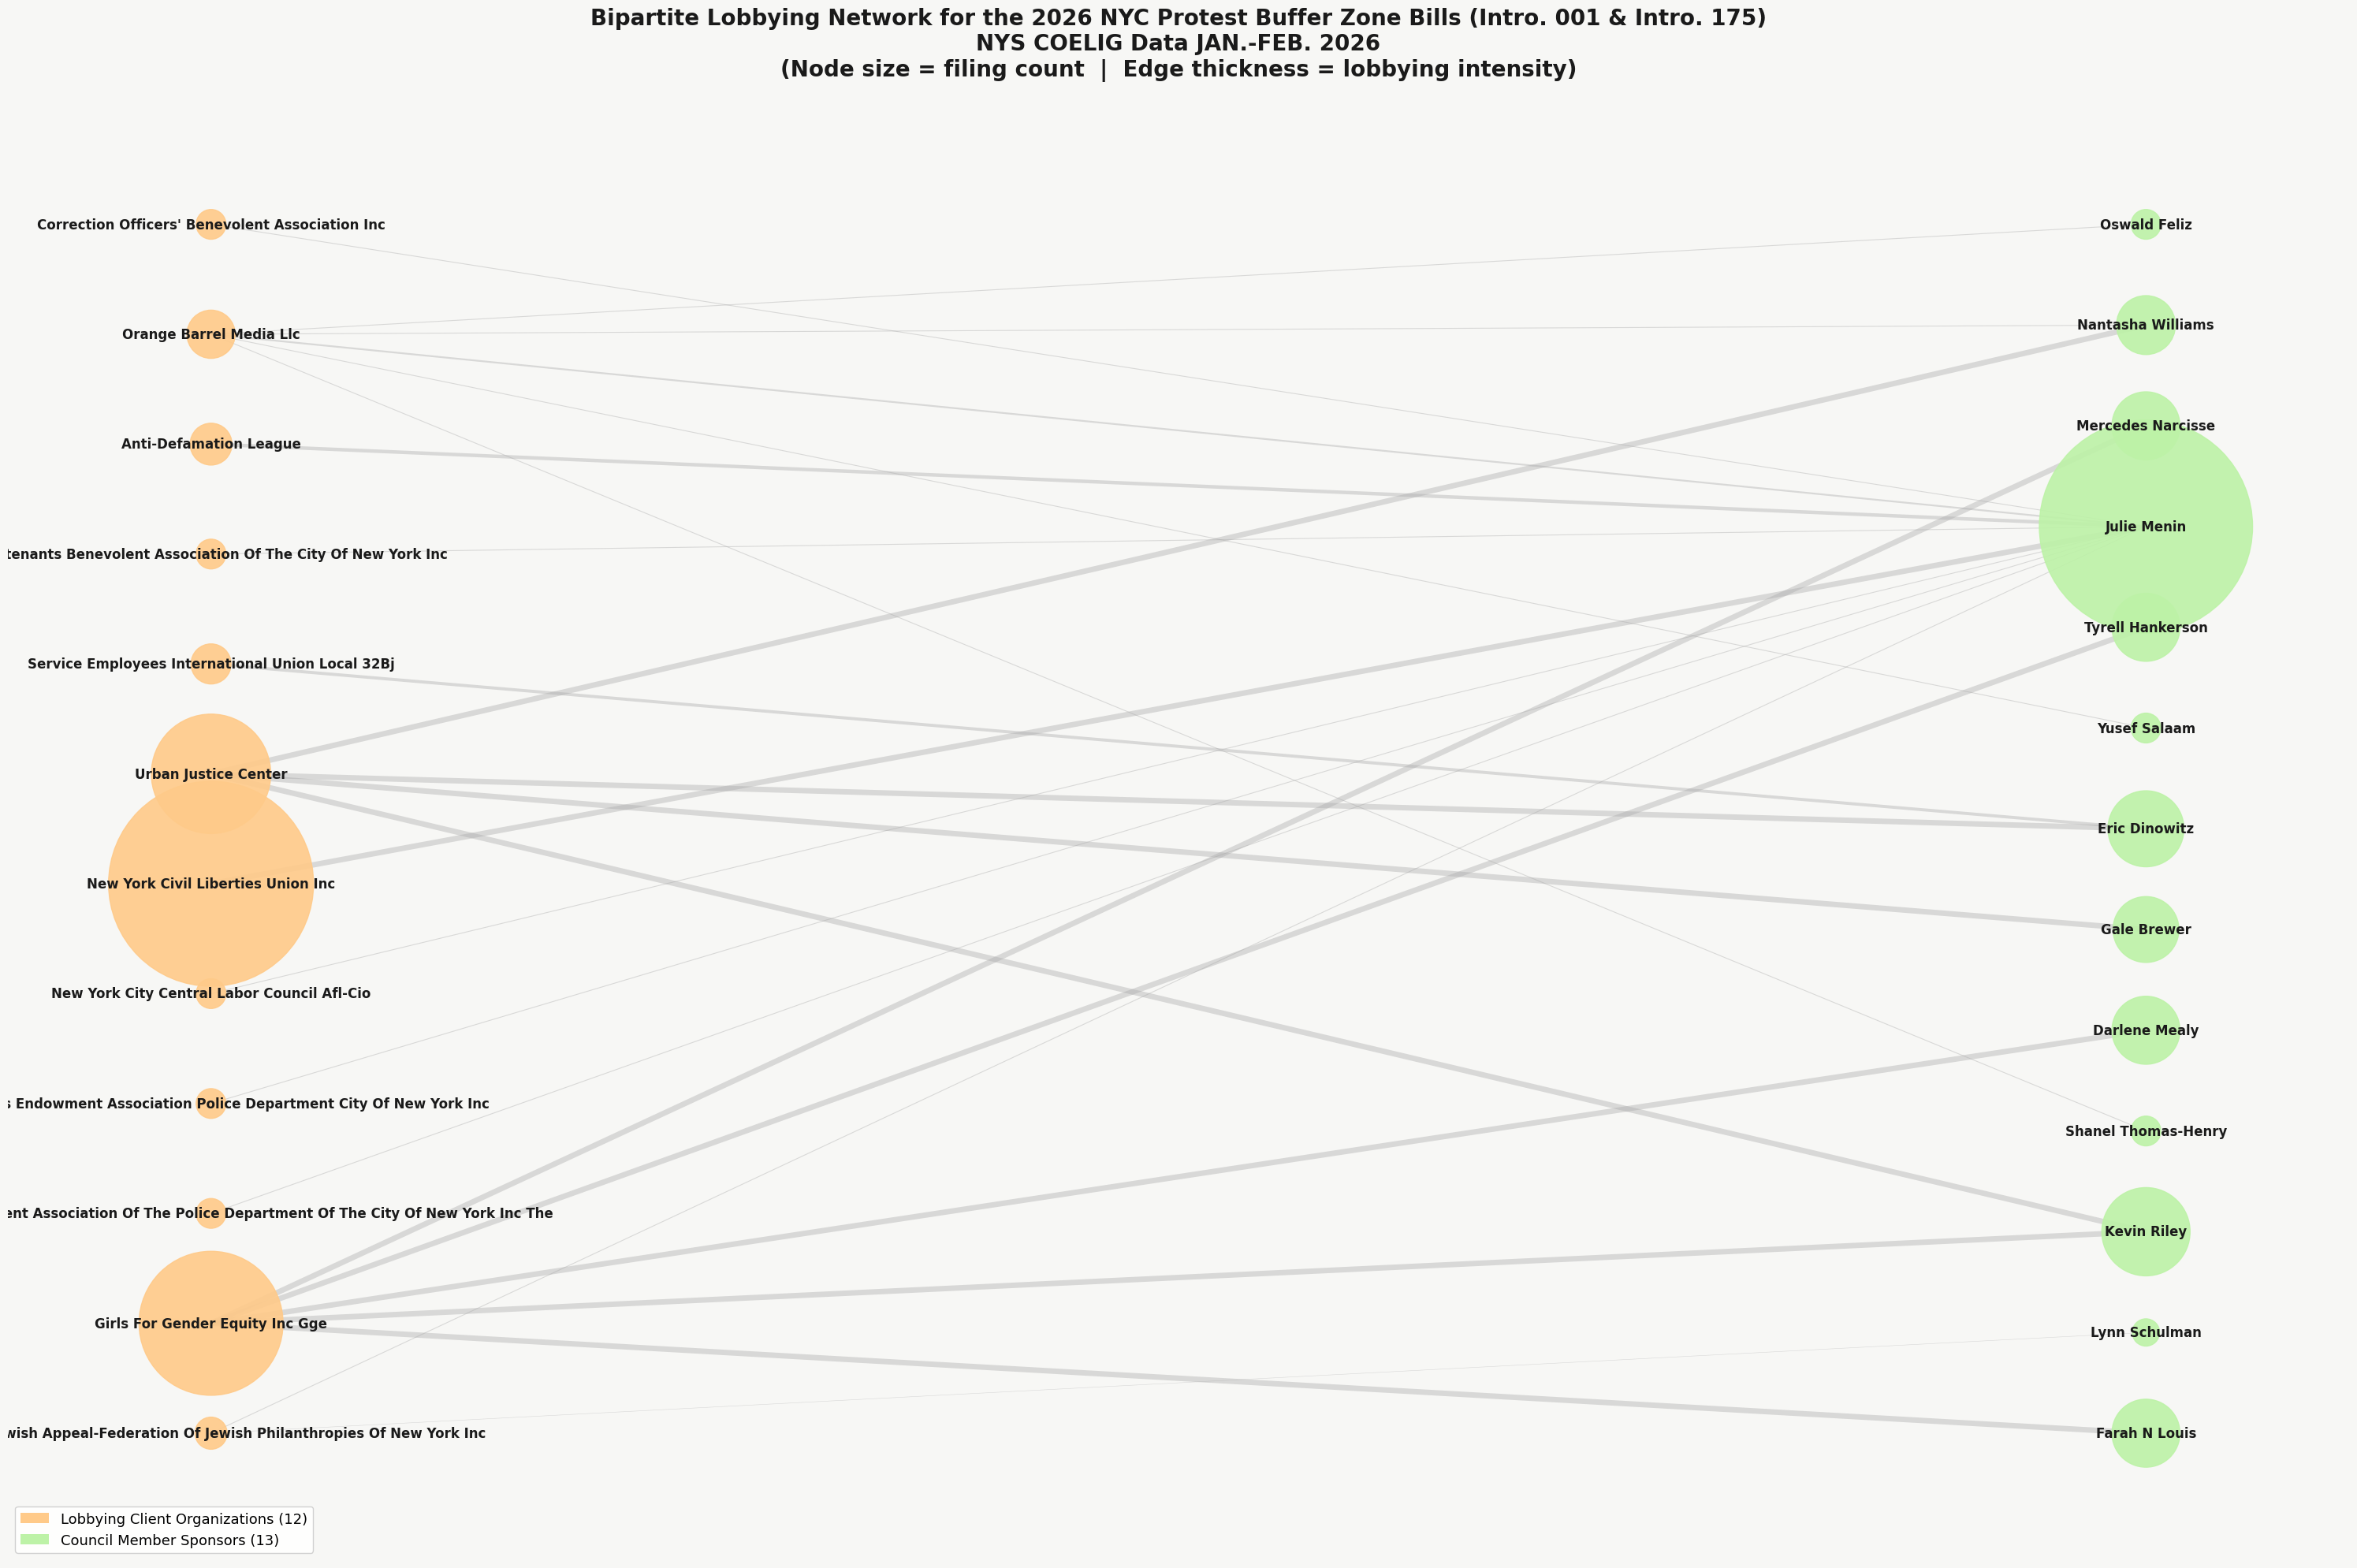

In [228]:
### The full Bipartite Network of Clients and Council Members 
fig, ax = plt.subplots(figsize=(30, 20), facecolor='#F7F7F5')
ax.set_facecolor('#F7F7F5')
pos_bip = nx.bipartite_layout(B, client_nodes, align='vertical', scale=3)
### Node styling
bip_colors = ['#ffca89' if n.startswith('C:') else '#bdf2a7' for n in B.nodes()]
bip_sizes  = [500 + B.nodes[n].get('filing_count', 0) * 120 for n in B.nodes()]
bip_widths = [min(B[u][v].get('weight', 1) * 0.4, 5) for u, v in B.edges()]
### Draw edges
nx.draw_networkx_edges(B, pos_bip,width = bip_widths,edge_color = '#AAAAAA', alpha= 0.4, ax= ax)
### Draw nodes and Labels 
nx.draw_networkx_nodes(B, pos_bip,node_color = bip_colors, node_size  = bip_sizes,alpha= 0.9, ax = ax)
bip_labels = {}
for n in B.nodes():
    if n.startswith('C:'):
        bip_labels[n] = n[2:].title().strip()
    else:
        ### Strip "nyc council member" prefix for readability
        bip_labels[n] = n[2:].replace('nyc council member ', '').title().strip()
nx.draw_networkx_labels(B, pos_bip,labels= bip_labels,font_size= 12, font_weight = 'bold', font_color  = '#1A1A1A',ax= ax)

### Legend and title
ax.legend(handles=[ mpatches.Patch(facecolor='#ffca89', label=f'Lobbying Client Organizations ({len(client_nodes)})'),
                    mpatches.Patch(facecolor='#bdf2a7', label=f'Council Member Sponsors ({len(council_nodes)})'),],
          fontsize=13, loc='lower left', framealpha=0.9)

ax.set_title(
    "Bipartite Lobbying Network for the 2026 NYC Protest Buffer Zone Bills (Intro. 001 & Intro. 175)\n"
    "NYS COELIG Data JAN.-FEB. 2026\n"
    "(Node size = filing count  |  Edge thickness = lobbying intensity)",
    fontsize=20, fontweight='bold', pad=20, color='#1A1A1A'
)
ax.axis('off')
plt.tight_layout()
plt.show()

C:\Users\jferrara_personal\AppData\Local\Temp\ipykernel_150808\2209337447.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cli   = plt.cm.get_cmap('tab10', max(len(client_communities), 1))


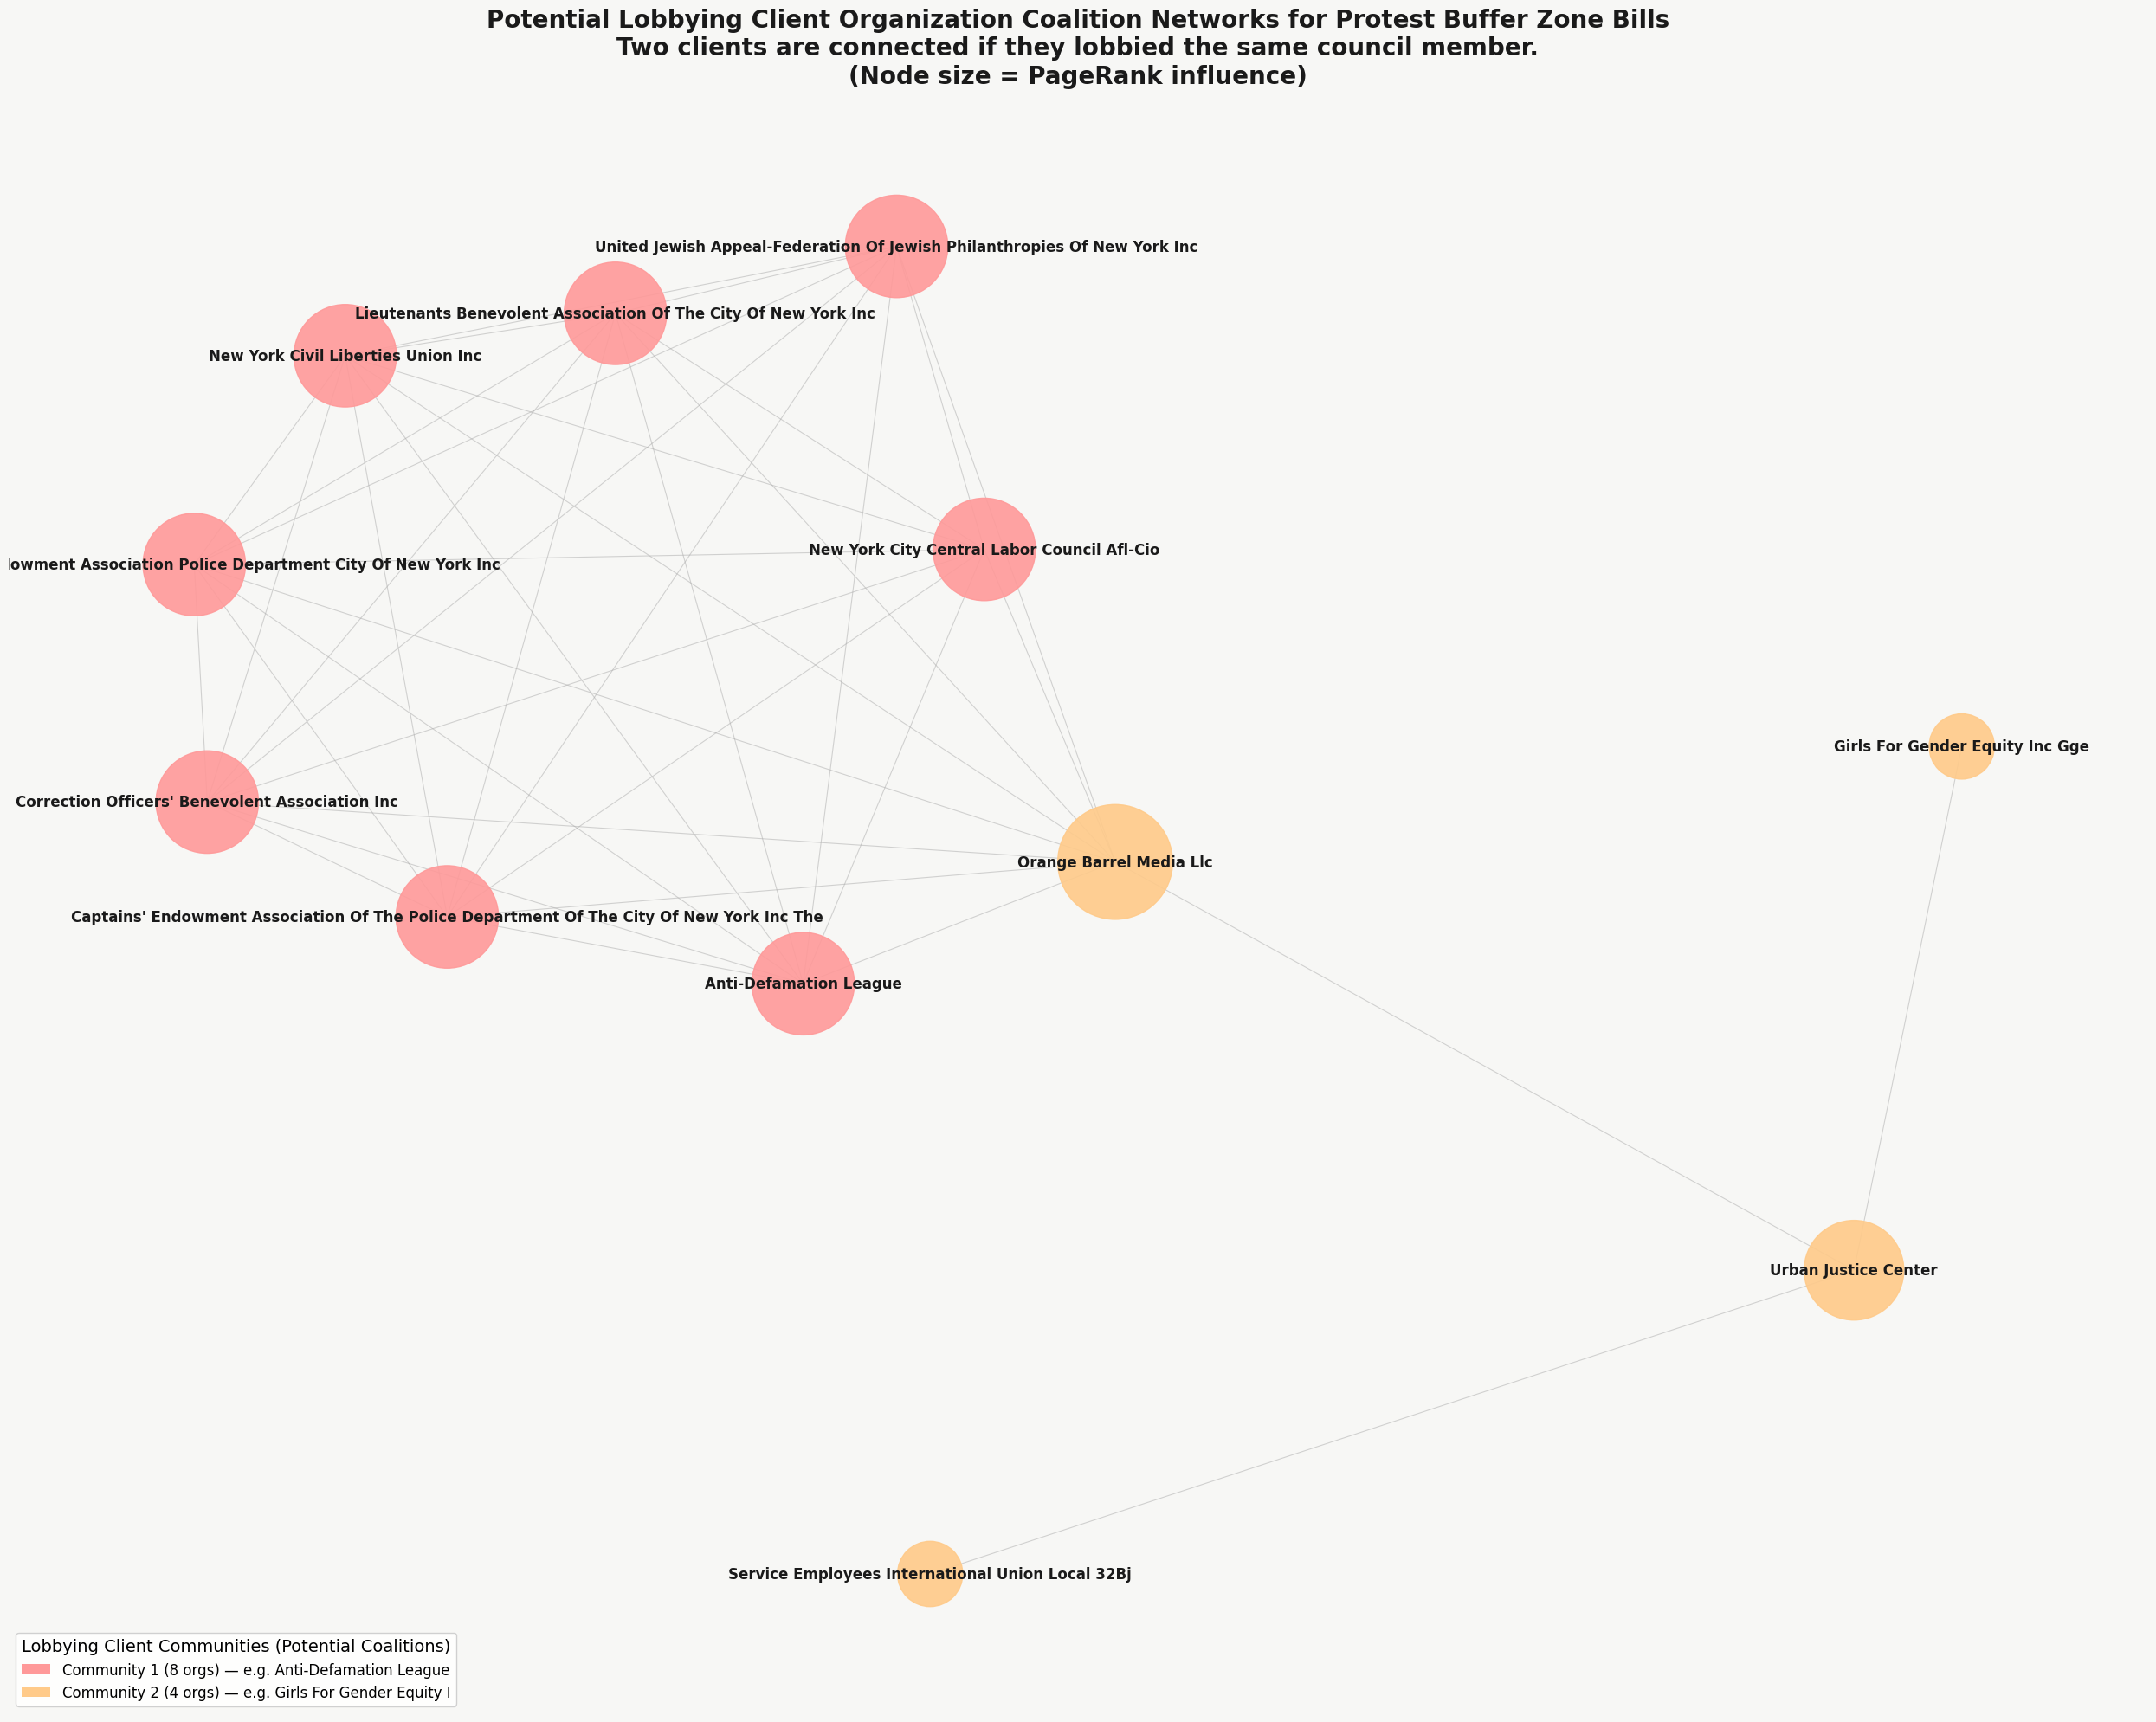

In [215]:
### The potential communities found on the Lobbying Client side 
fig, ax = plt.subplots(figsize=(25, 20), facecolor='#F7F7F5')
ax.set_facecolor('#F7F7F5')
pos_cli = nx.spring_layout(G_client, seed=42, k=3.5, iterations=100)
cmap_cli   = plt.cm.get_cmap('tab10', max(len(client_communities), 1))
COMMUNITY_COLORS = ['#ff9999', '#ffca89']
cli_colors = [COMMUNITY_COLORS[client_comm_map.get(n, 0) % len(COMMUNITY_COLORS)]for n in G_client.nodes()]
### Node sizes by PageRank (how important the nodes as based on the number of connectioend with other well connected nodes_
cli_pr    = nx.pagerank(G_client, weight='weight')
cli_sizes = [cli_pr.get(n, 0.01) * 80000 for n in G_client.nodes()]

### Edge thickness by weight (number of instances of lobbying )
cli_widths = [min(G_client[u][v].get('weight', 1) * 0.8, 6)
              for u, v in G_client.edges()]

nx.draw_networkx_edges(G_client, pos_cli, width = cli_widths, edge_color = '#AAAAAA', alpha = 0.5, ax = ax)
nx.draw_networkx_nodes(G_client, pos_cli, node_color = cli_colors, node_size  = cli_sizes, alpha = 0.9,ax = ax)
nx.draw_networkx_labels(G_client, pos_cli, labels= {n: n.title() for n in G_client.nodes()},
                        font_size   = 12, font_weight = 'bold', font_color  = '#1A1A1A', ax= ax)

### Build community legend dynamically
comm_handles = []
for i, comm in enumerate(sorted(client_communities, key=len, reverse=True)):
    sample = sorted(list(comm))[0].title()[:25]
    comm_handles.append( mpatches.Patch(facecolor = COMMUNITY_COLORS[i % len(COMMUNITY_COLORS)], label = f"Community {i+1} ({len(comm)} orgs) — e.g. {sample}") )
ax.legend(handles=comm_handles,
          fontsize=12, loc='lower left',
          framealpha=0.9, title="Lobbying Client Communities (Potential Coalitions)", title_fontsize=14)

ax.set_title(
    "Potential Lobbying Client Organization Coalition Networks for Protest Buffer Zone Bills\n"
    "Two clients are connected if they lobbied the same council member.\n"
    "(Node size = PageRank influence)",
    fontsize=20, fontweight='bold', pad=20, color='#1A1A1A'
)
ax.axis('off')
plt.tight_layout()
plt.show()

C:\Users\jferrara_personal\AppData\Local\Temp\ipykernel_150808\2734407021.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cm   = plt.cm.get_cmap('Set2', max(len(council_communities), 1))


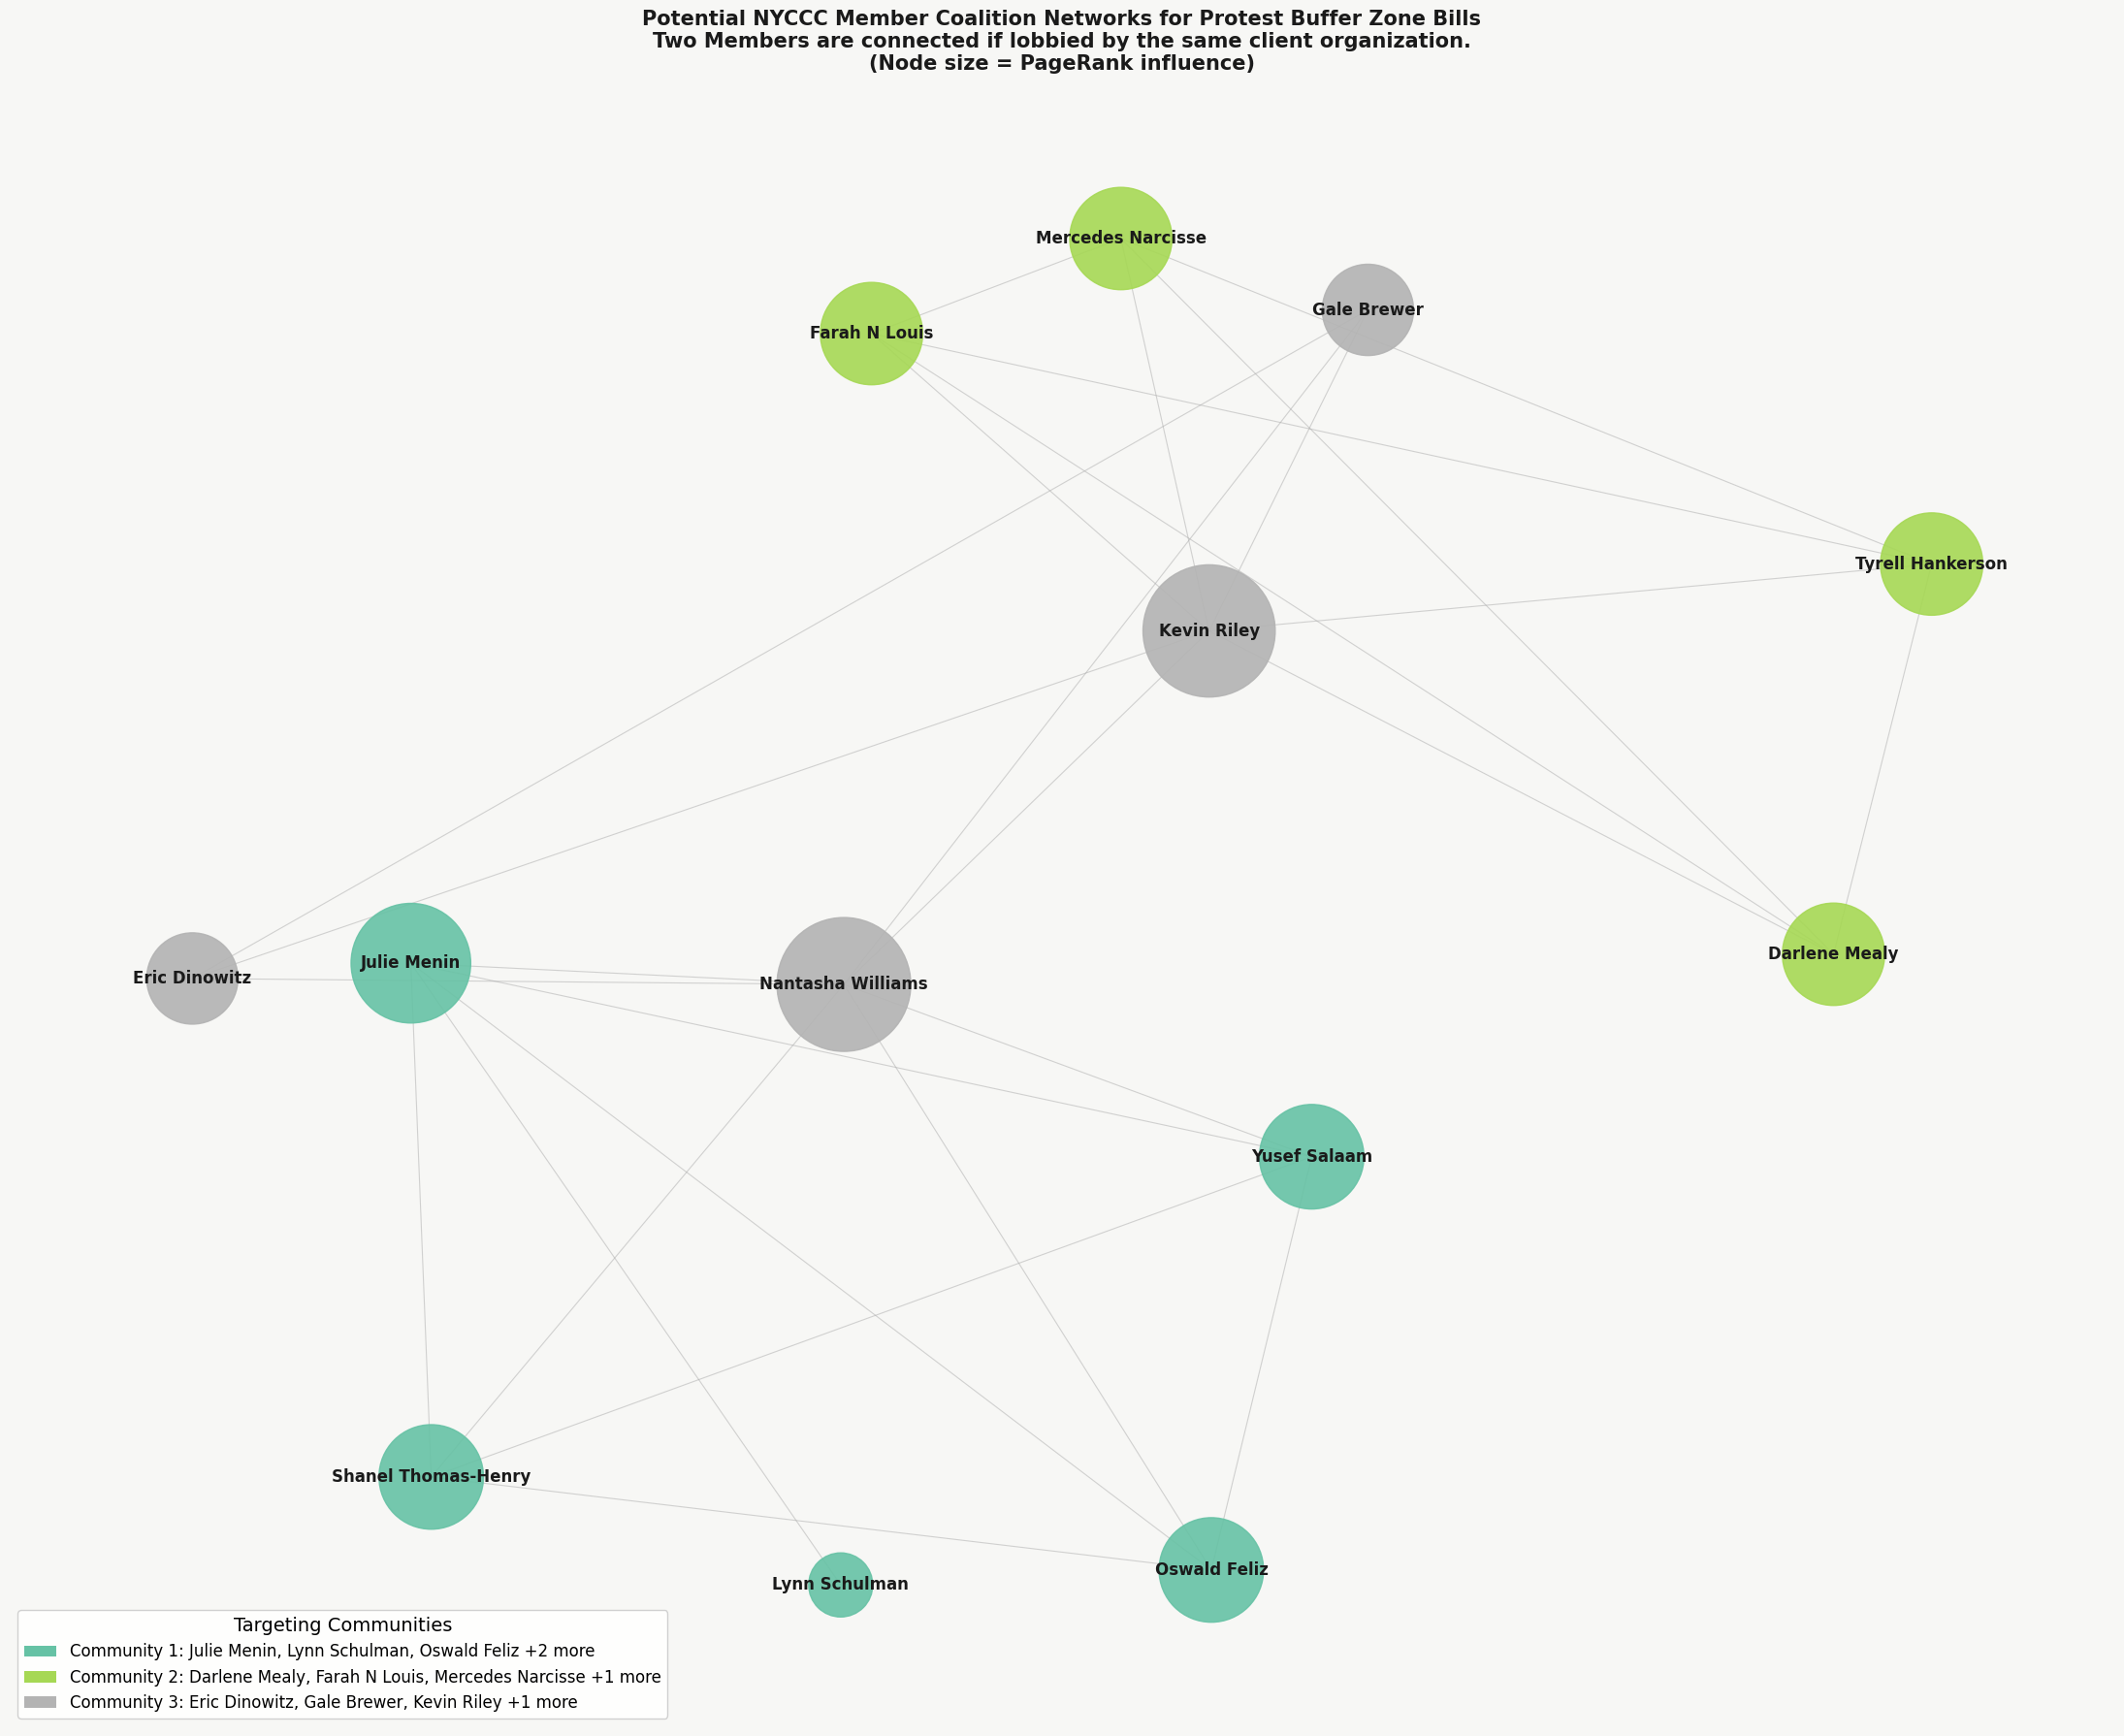

In [214]:
### The potential communities found on the NYCCC Member side 
fig, ax = plt.subplots(figsize=(22, 18), facecolor='#F7F7F5')
ax.set_facecolor('#F7F7F5')
pos_cm = nx.spring_layout(G_council, seed=99, k=3.5, iterations=100)
cmap_cm   = plt.cm.get_cmap('Set2', max(len(council_communities), 1))
cm_colors = [cmap_cm(council_comm_map.get(n, 0) % 8) for n in G_council.nodes()]

### Node sizes by PageRank (how important the nodes as based on the number of connectioend with other well connected nodes_
cm_pr     = nx.pagerank(G_council, weight='weight')
cm_sizes  = [cm_pr.get(n, 0.01) * 80000 for n in G_council.nodes()]
### Edge thickness
cm_widths = [min(G_council[u][v].get('weight', 1) * 0.8, 6) for u, v in G_council.edges()]
### Clean labels 
cm_labels = {    n: n.replace('nyc council member ', '').title()    for n in G_council.nodes()}

nx.draw_networkx_edges(G_council, pos_cm, width= cm_widths, edge_color = '#AAAAAA',alpha= 0.5,ax = ax)
nx.draw_networkx_nodes(G_council, pos_cm, node_color = cm_colors, node_size  = cm_sizes, alpha = 0.9, ax = ax)
nx.draw_networkx_labels(G_council, pos_cm, labels= cm_labels, font_size   = 12,font_weight = 'bold', font_color  = '#1A1A1A',ax = ax)

### Community legend
cm_comm_handles = []
for i, comm in enumerate(sorted(council_communities, key=len, reverse=True)):
    members_preview = ', '.join([
        m.replace('nyc council member ', '').title()
        for m in sorted(list(comm))[:3]
    ])
    if len(comm) > 3:
        members_preview += f' +{len(comm)-3} more'
    cm_comm_handles.append(
        mpatches.Patch(
            facecolor = cmap_cm(i % 8),
            label     = f"Community {i+1}: {members_preview}"
        )
    )
ax.legend(handles     = cm_comm_handles,
          fontsize    = 12,
          loc         = 'lower left',
          framealpha  = 0.9,
          title       = "NYCCC Member Communities (Potential Coalitions)",
          title_fontsize = 14)

ax.set_title(
    "Potential NYCCC Member Coalition Networks for Protest Buffer Zone Bills\n"
    "Two Members are connected if lobbied by the same client organization.\n"
    "(Node size = PageRank influence)",
    fontsize=15, fontweight='bold', pad=20, color='#1A1A1A'
)
ax.axis('off')
plt.tight_layout()
plt.show()

#### Main Takeways 
- Nantasha Williams and Kevin Riley emerged as the most central council members across all three measures — degree, betweenness, and PageRank.
- Speaker Menin ranked third on PageRank, meaning the lobbying effort attempted to build wider support than just her.
- The client Orange Barrel Media LLC was the top actor by both betweenness and PageRank. THis is bizzarre because it is a media firm, not an advocacy group.
- Using constraint scores, assuming those with the lowest were lynchpins of potential atypical coalitions, 
  an attempt was made to model who were the "power Brokers" on each side of this network. 
- Lastly, attempts at community / coalition detection showed that there were sub-blocs within this data that showed how siloed this groups are.
- Greedy modularity maximization was used to identify these communities, with the modularity scores acting as a "goodness" metric. The higher value here implies the detected communities are more separated from the others.

####  Noteworthy Limitations
This analysis is inherently limited because the lobbying effort's and clients positions on the bill are not in the data. It would be interesting 
to expand this analysis to all NYCCC Members along with the lobbying parties positions on the bill. In line with this missing information, the analysis
is limited to what uis formally filed with NYS. 

